# `04_robustez.ipynb` — Robustez à taxa de mascaramento

**Etapa 5 — Avaliação · notebook 4 de 4**

## Objetivo

Medir como GAIN e baselines **degradam quando a esparsidade do input aumenta**. Um
imputador bom não deveria desmoronar quando há mais buracos para preencher — e esse é o
regime real deste dataset, cronicamente esparso.

> **Pergunta:** como GAIN × baselines se degradam quando a taxa de mascaramento sobe? A
> GAIN depende de dados densos ou se mantém estável?

## Protocolo experimental

- **Taxas de mascaramento artificial:** `miss_rate ∈ {0.10, 0.20, 0.30, 0.50}`
  (uniforme sobre as células observadas — a mesma máquina `generate_artificial_mask`).
- **Sementes:** `[42, 7, 2026]` por taxa (as mesmas das Etapas 3–5).
- Para cada `(taxa, seed)`: esconder as células `(M=1, B=0)`, imputar com cada método,
  medir RMSE/MAE **na escala física** nas células escondidas — via
  `baseline_utils.avaliar_baseline`, o **mesmo** protocolo dos notebooks anteriores.
- Métrica agregada entre variáveis = **RMSE_norm** (espaço `[-1,1]`, comparável;
  a média em escala física entre variáveis não faria sentido).

**Reprodução dos baselines.** Diferente dos nb01–03 (que reusaram as predições persistidas,
válidas só para `miss_rate=0.20`), aqui reexecutamos os 7 imputadores em cada taxa,
reproduzindo **exatamente** as `predict_fn` da Etapa 3 (verificado: em `0.20` os números
batem com `baselines_{simples,ml}.csv`). Os imputadores de sklearn (KNN/MICE/MissForest)
são **ajustados uma vez por seed e reaproveitados entre as taxas** — o `fit` depende só do
`train`, então isso é idêntico numericamente e evita reajustar o MissForest 12×.

> Coliformes fica fora (0 obs. no test) → **10 variáveis avaliáveis**, não 13 do plano.

In [1]:
import sys, json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import IterativeImputer, KNNImputer

ROOT = Path.cwd()
while not (ROOT / "Data").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
CODE = ROOT / "Code"
sys.path.insert(0, str(CODE / "3 - Preprocessing"))
sys.path.insert(0, str(CODE / "4 - Baseline"))
sys.path.insert(0, str(CODE / "5 - GAIN"))
import gain
import baseline_utils as bu
from mask_utils import generate_artificial_mask

SPLIT_DIR = ROOT / "Data/GoldData/Splited"
MASK_DIR  = ROOT / "Data/GoldData/Masked"
PROC_DIR  = ROOT / "Data/ProcessedData"
BASE_TAB  = CODE / "4 - Baseline/tabelas"
CKPT      = CODE / "5 - GAIN/checkpoints/gain_best.pt"
OUT_TAB = CODE / "6 - Evaluation/tabelas"
OUT_FIG = ROOT / "Data/Figures/05_Evaluation"
for d in (OUT_TAB, OUT_FIG): d.mkdir(parents=True, exist_ok=True)

RATES = [0.10, 0.20, 0.30, 0.50]
SEEDS = [42, 7, 2026]
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.width", 180)
print("setup ok |", f"taxas={RATES} seeds={SEEDS}")

setup ok | taxas=[0.1, 0.2, 0.3, 0.5] seeds=[42, 7, 2026]


## 3. Dados e funções de imputação (reprodução fiel da Etapa 3)

In [2]:
with open(PROC_DIR / "encoded_columns.json", encoding="utf-8") as f:
    ec = json.load(f)
VARS = ec["numericas"]
CONTEXT_COLS = ec["temporais"] + ec["estacao_onehot"] + ec["ld_onehot"]
FEATURES = VARS + CONTEXT_COLS

df_train = pd.read_parquet(SPLIT_DIR / "train.parquet")
df_test  = pd.read_parquet(SPLIT_DIR / "test.parquet")
mask_real_test = pd.read_parquet(MASK_DIR / "mask_real_test.parquet")
scalers = joblib.load(PROC_DIR / "scalers.pkl")   # artefato local do projeto (confiável)
with open(PROC_DIR / "transform_params.json", encoding="utf-8") as f:
    transform_params = json.load(f)
train_feat = df_train[FEATURES]

# --- GAIN (checkpoint local da Etapa 4; weights_only=False p/ ler hp/vars junto) ---
ck = torch.load(CKPT, map_location="cpu", weights_only=False)
G = gain.Generator(len(ck["vars"]), len(ck["context_cols"]), ck["hp"]["hidden"])
G.load_state_dict(ck["G_state"]); G.eval()
ctx_test = torch.tensor(df_test[ck["context_cols"]].to_numpy(dtype=np.float32))

def predict_gain(X_obs, seed=None):
    m = torch.tensor(X_obs.notna().to_numpy(dtype=np.float32))
    x = torch.tensor(X_obs.fillna(0.0).to_numpy(dtype=np.float32))
    return pd.DataFrame(gain.impute(G, x, m, ctx_test).numpy(), columns=VARS, index=X_obs.index)

# --- Baselines simples (estatísticas do train) ---
media_train    = df_train[VARS].mean()
mediana_train  = df_train[VARS].median()
estacao_train  = bu.coluna_estacao(df_train)
estacao_test   = bu.coluna_estacao(df_test)
media_por_estacao = df_train[VARS].groupby(estacao_train.to_numpy()).mean()
ordem_temporal = df_test.assign(_e=estacao_test.to_numpy()).sort_values(["_e", "Data"]).index

def predict_media_global(X_obs, seed=None):   return X_obs.fillna(media_train)
def predict_mediana_global(X_obs, seed=None): return X_obs.fillna(mediana_train)
def predict_media_estacao(X_obs, seed=None):
    base = media_por_estacao.reindex(estacao_test.to_numpy()); base.index = X_obs.index
    return X_obs.fillna(base).fillna(media_train)
def predict_ffill_estacao(X_obs, seed=None):
    X_ord = X_obs.loc[ordem_temporal]; g = estacao_test.loc[ordem_temporal].to_numpy()
    X_fill = X_ord.groupby(g).ffill().groupby(g).bfill()
    return X_fill.loc[X_obs.index].fillna(media_train)

# --- Baselines sklearn com fit cacheado por seed (idêntico à Etapa 3, sem reajustar por taxa) ---
def fazer_predict_sklearn(fabrica):
    cache = {}
    def predict_fn(X_obs, seed):
        if seed not in cache:
            imp = fabrica(seed); imp.fit(train_feat); cache[seed] = imp
        out = cache[seed].transform(pd.concat([X_obs, df_test[CONTEXT_COLS]], axis=1))
        return pd.DataFrame(out, columns=FEATURES, index=X_obs.index)[VARS]
    return predict_fn

predict_knn = fazer_predict_sklearn(lambda s: KNNImputer(n_neighbors=5, weights="distance"))
predict_mice = fazer_predict_sklearn(lambda s: IterativeImputer(max_iter=10, random_state=s))
predict_missforest = fazer_predict_sklearn(lambda s: IterativeImputer(
    estimator=RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=s),
    max_iter=10, random_state=s))

METODOS = {
    "gain": predict_gain, "knn": predict_knn, "mice": predict_mice,
    "missforest": predict_missforest, "media_estacao": predict_media_estacao,
    "media_global": predict_media_global, "mediana_global": predict_mediana_global,
    "ffill_estacao": predict_ffill_estacao,
}
print(f"{len(METODOS)} métodos prontos | {len(VARS)} variáveis-alvo | {len(FEATURES)} features")

8 métodos prontos | 11 variáveis-alvo | 34 features


## 4. Loop experimental — 4 taxas × 3 seeds × 8 métodos

`avaliar_baseline` já percorre as 3 seeds e devolve as métricas por seed × variável (com a
coluna `miss_rate`). Acumulamos tudo numa base longa. MissForest é o gargalo (~2 min).

In [3]:
registros = []
for taxa in RATES:
    for nome, fn in METODOS.items():
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", message=".*did not converge.*")
            met, _ = bu.avaliar_baseline(
                nome, fn, df_test, mask_real_test, VARS, scalers, transform_params,
                seeds=SEEDS, miss_rate=taxa, generate_artificial_mask=generate_artificial_mask)
        registros.append(met)
    print(f"taxa {taxa:.2f} concluída")
long = pd.concat(registros, ignore_index=True)
print(f"\nbase longa: {long.shape[0]} linhas "
      f"(esperado {len(RATES)}×{len(METODOS)}×10×{len(SEEDS)} = {len(RATES)*len(METODOS)*10*len(SEEDS)})")

# Sanidade: em miss_rate=0.20, KNN/MissForest batem a Etapa 3
etapa3 = pd.read_csv(BASE_TAB / "baselines_ml.csv", encoding="utf-8")
for m in ["knn", "missforest"]:
    a = long[(long.metodo==m) & (long.miss_rate==0.20)]["RMSE_norm"].mean()
    b = etapa3[etapa3.metodo==m]["RMSE_norm"].mean()
    print(f"  {m}: reprodução @0.20 = {a:.4f} | Etapa 3 = {b:.4f} | Δ={abs(a-b):.2e}")

C:\Users\jhter\OneDrive\Documents\QualiAgua\venv\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


C:\Users\jhter\OneDrive\Documents\QualiAgua\venv\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


C:\Users\jhter\OneDrive\Documents\QualiAgua\venv\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


C:\Users\jhter\OneDrive\Documents\QualiAgua\venv\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


C:\Users\jhter\OneDrive\Documents\QualiAgua\venv\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


...

C:\Users\jhter\OneDrive\Documents\QualiAgua\venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
C:\Users\jhter\OneDrive\Documents\QualiAgua\venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
C:\Users\jhter\OneDrive\Documents\QualiAgua\venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
C:\Users\jhter\OneDrive\Docu

C:\Users\jhter\OneDrive\Documents\QualiAgua\venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
C:\Users\jhter\OneDrive\Documents\QualiAgua\venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
C:\Users\jhter\OneDrive\Documents\QualiAgua\venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
C:\Users\jhter\OneDrive\Docu

taxa 0.20 concluída


taxa 0.30 concluída


taxa 0.50 concluída

base longa: 960 linhas (esperado 4×8×10×3 = 960)
  knn: reprodução @0.20 = 0.3127 | Etapa 3 = 0.3127 | Δ=5.55e-17
  missforest: reprodução @0.20 = 0.3469 | Etapa 3 = 0.3469 | Δ=5.55e-17


## 5. Persistência

`robustez.csv` agrega por `(metodo, miss_rate)` sobre as 10 variáveis × 3 seeds (RMSE_norm
= métrica comparável). A base longa por variável×seed vai para `robustez_long.csv` (o
detalhe que o critério de aceite pede).

In [4]:
long.to_csv(OUT_TAB / "robustez_long.csv", index=False, encoding="utf-8")

robustez = (long.groupby(["metodo", "miss_rate"])
            .agg(RMSE_mean=("RMSE_norm", "mean"), RMSE_std=("RMSE_norm", "std"),
                 MAE_mean=("MAE_norm", "mean"),
                 RMSE_orig_mean=("RMSE", "mean"), n=("RMSE_norm", "size"))
            .reset_index())
robustez.to_csv(OUT_TAB / "robustez.csv", index=False, encoding="utf-8")
print(f"salvos: robustez.csv ({len(robustez)} linhas) e robustez_long.csv ({len(long)} linhas)")

ordem_met = robustez.groupby("metodo")["RMSE_mean"].mean().sort_values().index.tolist()
robustez.pivot(index="metodo", columns="miss_rate", values="RMSE_mean").reindex(ordem_met).round(4)

salvos: robustez.csv (32 linhas) e robustez_long.csv (960 linhas)


miss_rate,0.1,0.2,0.3,0.5
metodo,,,,
knn,0.2922,0.3127,0.3174,0.3266
gain,0.3077,0.3117,0.3299,0.3430
mice,0.3455,0.3328,0.3436,0.3382
missforest,0.3278,0.3469,0.3469,0.3468
media_estacao,0.3415,0.3497,0.3533,0.3514
media_global,0.3761,0.3762,0.3730,0.3802
mediana_global,0.3879,0.3850,0.3810,0.3899
ffill_estacao,0.3277,0.3979,0.4245,0.4388


## 6. Visualizações

Curvas `RMSE_norm × miss_rate` (banda = ±desvio entre variáveis×seeds), GAIN em destaque;
e heatmap `método × taxa`. Curvas mais **baixas e planas** = método melhor e mais robusto.

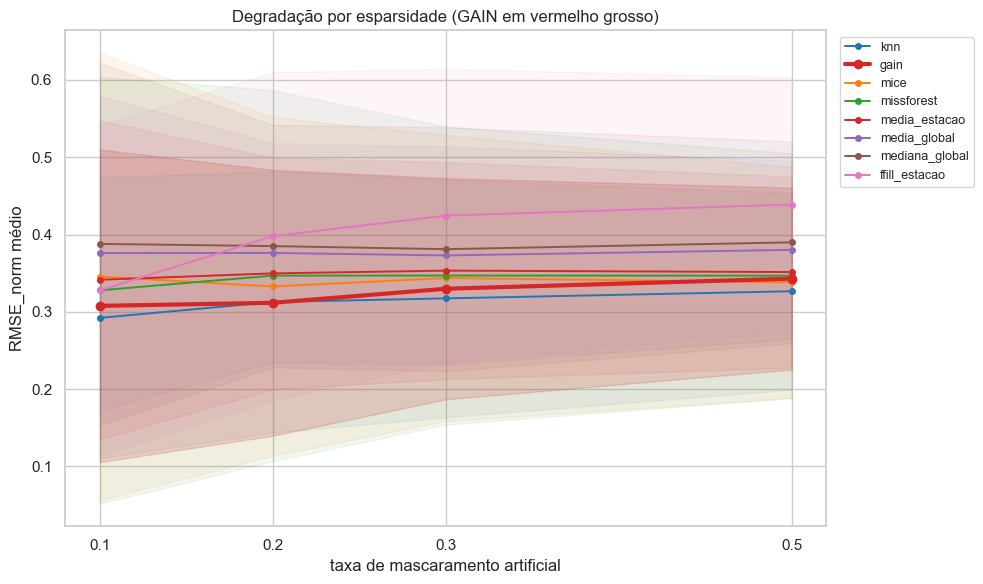

figura salva: robustez_curvas.png


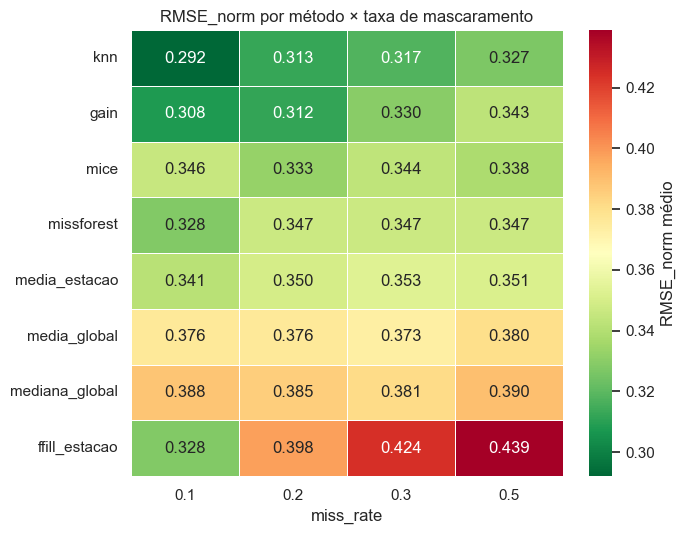

figura salva: robustez_heatmap.png


In [5]:
paleta = {m: c for m, c in zip([x for x in ordem_met if x != "gain"],
          sns.color_palette("tab10", len(ordem_met)-1))}
paleta["gain"] = "#d62728"

fig, ax = plt.subplots(figsize=(10, 6))
for m in ordem_met:
    sub = robustez[robustez.metodo == m].sort_values("miss_rate")
    lw = 3 if m == "gain" else 1.4
    ax.plot(sub.miss_rate, sub.RMSE_mean, "-o", color=paleta[m], lw=lw,
            markersize=6 if m == "gain" else 4, label=m, zorder=6 if m=="gain" else 3)
    ax.fill_between(sub.miss_rate, sub.RMSE_mean - sub.RMSE_std,
                    sub.RMSE_mean + sub.RMSE_std, color=paleta[m],
                    alpha=0.18 if m == "gain" else 0.07)
ax.set_xlabel("taxa de mascaramento artificial"); ax.set_ylabel("RMSE_norm médio")
ax.set_xticks(RATES); ax.set_title("Degradação por esparsidade (GAIN em vermelho grosso)")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
fig.tight_layout(); fig.savefig(OUT_FIG / "robustez_curvas.png", dpi=130, bbox_inches="tight")
plt.show(); print(f"figura salva: robustez_curvas.png")

mat = robustez.pivot(index="metodo", columns="miss_rate", values="RMSE_mean").reindex(ordem_met)
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(mat, annot=True, fmt=".3f", cmap="RdYlGn_r", linewidths=.5,
            cbar_kws={"label": "RMSE_norm médio"}, ax=ax)
ax.set_title("RMSE_norm por método × taxa de mascaramento")
ax.set_xlabel("miss_rate"); ax.set_ylabel("")
fig.tight_layout(); fig.savefig(OUT_FIG / "robustez_heatmap.png", dpi=130, bbox_inches="tight")
plt.show(); print(f"figura salva: robustez_heatmap.png")

## 7. Degradação relativa

`(RMSE@0.5 − RMSE@0.1) / RMSE@0.1` em %. **Menor = mais robusto** à esparsidade. Cruze com
o nível de RMSE: um método pode ser plano por já ser ruim (piso alto), não por robustez real.

In [6]:
piv = robustez.pivot(index="metodo", columns="miss_rate", values="RMSE_mean")
degrad = pd.DataFrame({
    "RMSE@0.1": piv[0.10], "RMSE@0.5": piv[0.50],
    "degradacao_%": (100 * (piv[0.50] - piv[0.10]) / piv[0.10]),
    "RMSE_medio": piv.mean(axis=1),
}).sort_values("degradacao_%").round(3)
degrad.to_csv(OUT_TAB / "robustez_degradacao.csv", encoding="utf-8")
print("Degradação relativa 0.1→0.5 (menor = mais robusto):")
degrad

Degradação relativa 0.1→0.5 (menor = mais robusto):


,RMSE@0.1,RMSE@0.5,degradacao_%,RMSE_medio
metodo,,,,
mice,0.346,0.338,-2.128,0.340
mediana_global,0.388,0.390,0.520,0.386
media_global,0.376,0.380,1.093,0.376
media_estacao,0.341,0.351,2.916,0.349
missforest,0.328,0.347,5.790,0.342
gain,0.308,0.343,11.462,0.323
knn,0.292,0.327,11.795,0.312
ffill_estacao,0.328,0.439,33.896,0.397


## 8. Síntese — robustez

In [7]:
gain_deg = degrad.loc["gain", "degradacao_%"]
mais_robusto = degrad.index[0]
melhor_nivel = robustez.groupby("metodo")["RMSE_mean"].mean().idxmin()
pos_gain_deg = list(degrad.index).index("gain") + 1
pos_gain_nivel = robustez.groupby("metodo")["RMSE_mean"].mean().sort_values().index.get_loc("gain") + 1

print("SÍNTESE — ROBUSTEZ (test set)")
print("=" * 60)
print(f"Método MAIS ROBUSTO (menor degradação 0.1→0.5): {mais_robusto} "
      f"({degrad.loc[mais_robusto,'degradacao_%']:.1f}%)")
print(f"GAIN: degradação {gain_deg:.1f}% — {pos_gain_deg}º de {len(degrad)} em robustez")
print(f"Menor RMSE médio (nível): {melhor_nivel} | GAIN em {pos_gain_nivel}º de {len(degrad)}")
print("\nGAIN por taxa (RMSE_norm):")
for _, r in robustez[robustez.metodo=="gain"].sort_values("miss_rate").iterrows():
    print(f"   miss_rate {r.miss_rate:.2f}: {r.RMSE_mean:.4f} ± {r.RMSE_std:.3f}")
knn = robustez[robustez.metodo=="knn"].set_index("miss_rate")["RMSE_mean"]
gn  = robustez[robustez.metodo=="gain"].set_index("miss_rate")["RMSE_mean"]
print("\nGAIN − KNN por taxa (negativo = GAIN melhor):")
for t in RATES:
    print(f"   {t:.2f}: {gn[t]-knn[t]:+.4f}")

SÍNTESE — ROBUSTEZ (test set)
Método MAIS ROBUSTO (menor degradação 0.1→0.5): mice (-2.1%)
GAIN: degradação 11.5% — 6º de 8 em robustez
Menor RMSE médio (nível): knn | GAIN em 2º de 8

GAIN por taxa (RMSE_norm):
   miss_rate 0.10: 0.3077 ± 0.202
   miss_rate 0.20: 0.3117 ± 0.172
   miss_rate 0.30: 0.3299 ± 0.143
   miss_rate 0.50: 0.3430 ± 0.118

GAIN − KNN por taxa (negativo = GAIN melhor):
   0.10: +0.0156
   0.20: -0.0010
   0.30: +0.0125
   0.50: +0.0164


### Leitura

Duas coisas diferentes: **nível** (quão baixo é o RMSE) e **robustez** (quão pouco ele
sobe com a esparsidade). O ideal é curva baixa E plana. Cuidados:

1. Os baselines de média/mediana são quase planos **porque já partem de um piso alto** —
   robustez sem qualidade não vale nada. Leia a % de degradação junto do RMSE médio.
2. O regime real do QualiAgua é esparso; se a GAIN degrada **menos** que o KNN quando a
   taxa sobe, esse é o argumento operacional mais forte a favor dela — mais do que o
   empate no `miss_rate=0.20` dos nb01–02.

Este é o último notebook da Etapa 5. O `05_Evaluation/relatorio.md` deve consolidar os
quatro eixos: **erro pontual** (nb01), **distribuição** (nb02), **correlação** (nb03) e
**robustez** (nb04). Próxima etapa: `06_PostImputation/01_imputar_dataset.ipynb`.